# 📘 Домашнє завдання №16. Прогнозування часових рядів

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW16


# 📊 Дані

## 1. Датасет для ARIMA (без сезонності)

```python
import numpy as np
import pandas as pd

np.random.seed(42)

n = 200
time = np.arange(n)

trend = 0.1 * time
noise = np.random.normal(0, 1, n)

values = trend + noise

dates = pd.date_range(start='2020-01-01', periods=n, freq='D')

df_arima = pd.DataFrame({
    'ds': dates,
    'y': values
})
```

---

## 2. Датасет для SARIMA / ML / Prophet (із сезонністю)

```python
np.random.seed(42)

n = 240
time = np.arange(n)

trend = 0.05 * time
seasonality = 10 * np.sin(2 * np.pi * time / 12)
noise = np.random.normal(0, 2, n)

values = trend + seasonality + noise

dates = pd.date_range(start='2015-01-01', periods=n, freq='M')

df_seasonal = pd.DataFrame({
    'ds': dates,
    'y': values
})
```


# 🧠 Завдання

## 🔹 Завдання 1. Аналіз і візуалізація

Для обох датасетів:

1. Побудувати графік часового ряду
2. Побудувати:

   * ACF
   * PACF
3. Зробити висновки:

   * чи є тренд
   * чи є сезонність
   * який можливий період сезонності

---

## 🔹 Завдання 2. Побудова моделей

### 📌 2.1 ARIMA (для df_arima)

1. Перевірити стаціонарність (ADF тест)
2. При необхідності зробити диференціювання
3. Визначити параметри:

   * вручну через ACF/PACF
   * автоматично через auto_arima
4. Натренувати модель
5. Зробити прогноз

---

### 📌 2.2 SARIMA (для df_seasonal)

1. Визначити сезонність (період m)
2. Використати auto_arima (з seasonal=True)
3. Натренувати модель
4. Побудувати прогноз

---

### 📌 2.3 Prophet (для df_seasonal)

1. Переконатися, що дані мають формат:

   * ds — дата
   * y — значення

2. Натренувати модель:

```python
from prophet import Prophet

model = Prophet()
model.fit(df_seasonal)
```

3. Створити майбутні дати:

```python
future = model.make_future_dataframe(periods=24, freq='M')
```

4. Побудувати прогноз:

```python
forecast = model.predict(future)
```

5. Побудувати графіки:

* прогнозу
* компонентів (trend, seasonality)

---

### 📌 2.4 ML модель (для df_seasonal)

Обрати одну модель:

* XGBoost / RandomForest / CatBoost

1. Створити фічі:

   * lag_1, lag_2, lag_12
   * rolling статистики
   * календарні фічі (місяць, рік)

2. Розбити дані на train/test

3. Натренувати модель

4. Побудувати прогноз

---

## 🔹 Завдання 3. Візуальна оцінка

Для кожної моделі:

1. Побудувати графік:

   * train
   * test
   * forecast

2. Оцінити:

   * чи модель ловить тренд
   * чи модель ловить сезонність
   * чи є систематичні помилки

---

## 🔹 Завдання 4. Оцінка якості

Для кожної моделі обчислити:

* MAE
* RMSE
* MAPE

Порівняти:

* ARIMA (manual vs auto)
* SARIMA vs Prophet
* Prophet vs ML


In [1]:
# TODO: uncommit
# # Silent installation or update
#
# # Clean cache
# !python3 -m pip cache purge -q
#
# # Force updating
# package_update = [
#     "pip",
#     "scikit-learn",
# ]
#
# for package_name in package_update:
#     !bash -c "python3 -m pip install -U '{package_name}' -q"
#
# # Install missing packages
# package_array = [
#     "jinja2",
#     "ipywidgets",
#     "nbformat",
#     "kagglehub[pandas-datasets]",
#     "numpy",
#     "pandas",
#     "matplotlib",
#     "scipy",
#     "statsmodels",
#     "pmdarima",
#     "prophet",
#     "plotly",
#     "xgboost",
# ]
#
# for package_name in package_array:
#     !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# TODO: uncommit
# # Synchronization with remote source
#
# import shutil
# from pathlib import Path
#
# # Input data
# hm_version = 16
#
# # Solution
# git_project_url = f"https://github.com/BogdanPinchuk/DataScience-PBY_HW{hm_version}.git"
# main_file_name = f"Bohdan_Pinchuk_DS_HW{hm_version}.ipynb"
#
# # upload all files
# current_path = !pwd
# current_path = current_path[0]
# parent_path = !dirname "$current_path"
# parent_path = parent_path[0]
# temp_path = f"{parent_path}/temp"
#
# # Clone data
# !rm -rf "$temp_path"
# !git clone "$git_project_url" "$temp_path"
#
# source = Path(temp_path)
# destination = Path(current_path)
# exclude = {main_file_name, ".git", ".idea"}
#
# for item in source.iterdir():
#     if item.name in exclude:
#         continue
#
#     target = destination / item.name
#     if item.is_dir():
#         shutil.copytree(item, target, dirs_exist_ok=True)
#     else:
#         shutil.copy2(item, target)
#
# # Clean temp folder
# !rm -rf "$temp_path"

## ✳️ Підготовка датасетів

In [3]:
# Data synthesis - Датасет для ARIMA

import numpy as np
import pandas as pd
from IPython.display import display
from fontTools.diff import color

# Input data
rng_seed = 42
n = 200
pd.options.display.float_format = "{:g}".format

# Solution
np.random.seed(rng_seed)

time = np.arange(n)
trend = 0.1 * time
noise = np.random.normal(0, 1, n)
values = trend + noise
dates = pd.date_range(start='2020-01-01', periods=n, freq='D')

# створюємо DataFrame
ds_arima_name = "ARIMA (без сезонності)"
df_arima = pd.DataFrame({
    'ds': dates,
    'y': values,
})

# Print results
display(df_arima)

,ds,y
0,2020-01-01,0.496714
1,2020-01-02,-0.0382643
2,2020-01-03,0.847689
3,2020-01-04,1.82303
4,2020-01-05,0.165847
...,...,...
195,2020-07-14,19.8853
196,2020-07-15,18.7161
197,2020-07-16,19.8537
198,2020-07-17,19.8582


In [4]:
# Data synthesis - Датасет для SARIMA

import numpy as np
import pandas as pd
from IPython.display import display

# Input data
rng_seed = 42
n = 240

# Solution
np.random.seed(rng_seed)

time = np.arange(n)
trend = 0.05 * time
seasonality = 10 * np.sin(2 * np.pi * time / 12)
noise = np.random.normal(0, 2, n)
values = trend + seasonality + noise
dates = pd.date_range(start='2015-01-01', periods=n, freq='MS')  # початок кожного місяця

# створюємо DataFrame
ds_seasonal_name = "SARIMA / ML / Prophet (із сезонністю)"
df_seasonal = pd.DataFrame({
    'ds': dates,
    'y': values,
})

# Print results
display(df_seasonal)

,ds,y
0,2015-01-01,0.993428
1,2015-02-01,4.77347
2,2015-03-01,10.0556
3,2015-04-01,13.1961
4,2015-05-01,8.39195
...,...,...
235,2034-08-01,8.01784
236,2034-09-01,-0.910539
237,2034-10-01,2.22291
238,2034-11-01,1.91617


## ✅ Рішення 1

Для обох датасетів:

1. Побудувати графік часового ряду
2. Побудувати:

   * ACF
   * PACF
3. Зробити висновки:

   * чи є тренд
   * чи є сезонність
   * який можливий період сезонності

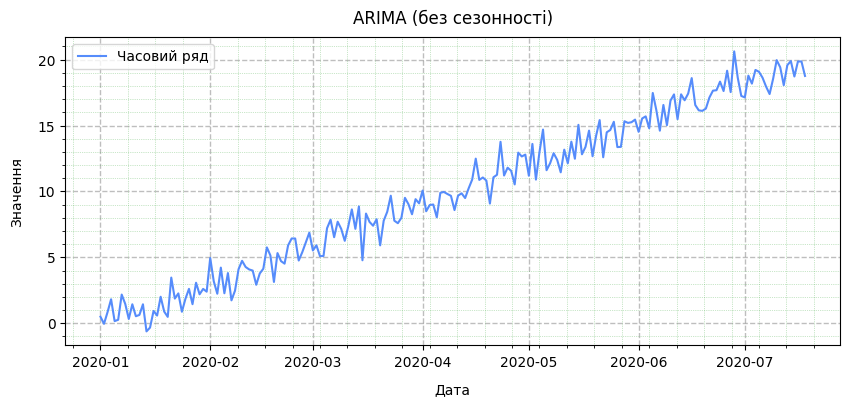

In [5]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_set = df_arima

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(data_set["ds"], data_set["y"], label="Часовий ряд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title(ds_arima_name, pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

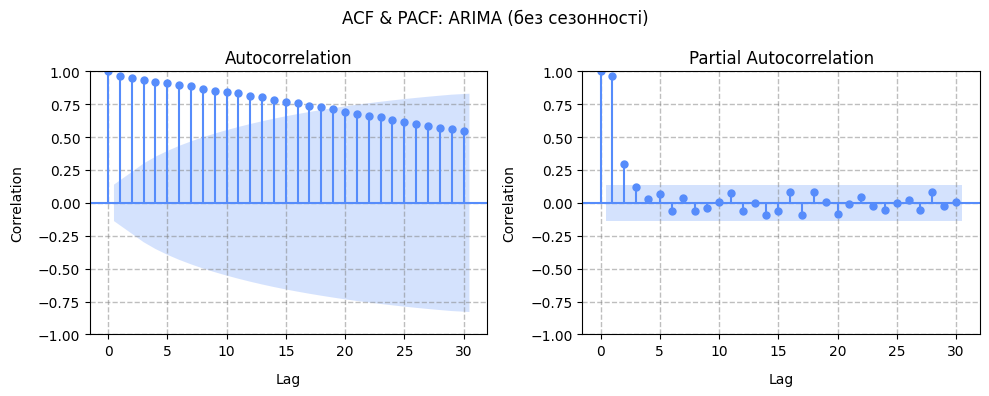

In [6]:
# Graphic results

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Input data
lags = 30
data_set = df_arima["y"]

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax = axes[0]
plot_acf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

ax = axes[1]
plot_pacf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

plt.suptitle(f"ACF & PACF: {ds_arima_name}")

plt.tight_layout()
plt.show()

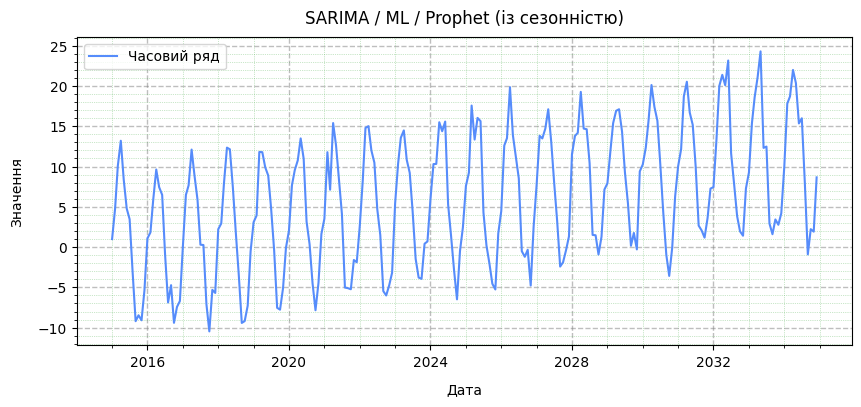

In [7]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_set = df_seasonal

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(data_set["ds"], data_set["y"], label="Часовий ряд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title(ds_seasonal_name, pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

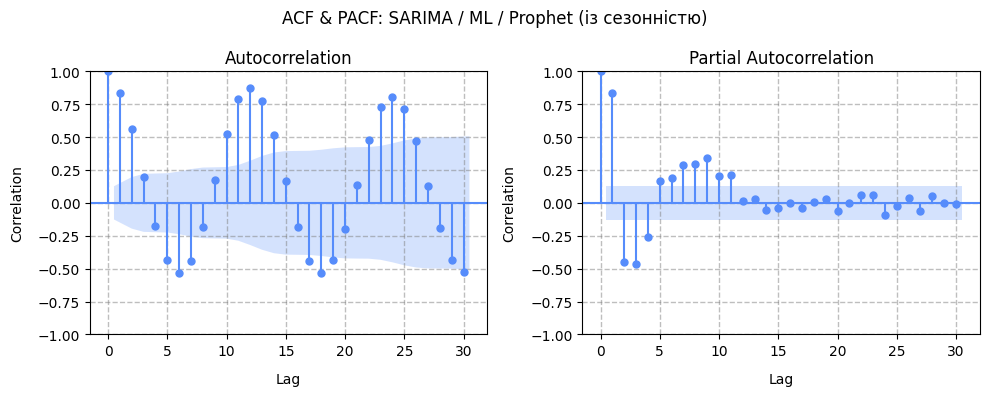

In [8]:
# Graphic results

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Input data
lags = 30
data_set = df_seasonal["y"]

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax = axes[0]
plot_acf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

ax = axes[1]
plot_pacf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

plt.suptitle(f"ACF & PACF: {ds_seasonal_name}")

plt.tight_layout()
plt.show()

* **ACF** — (автокореляція) відображає прямий і непрямий звʼязок із лагами.
* **PACF** — (часткова кореляція) відображає тільки прямий звʼязок із лагами.

Параметр    | графік ACF                 | графік PACF
------------|----------------------------|------------
AR(p)       | Затихає плавно             | Обривається різко на p лагу
MA(q)       | Обривається різко на q лагу | Затихає плавно

- **d** — кількість диференціювань до досягнення стаціонарності ряду.
- **p** — індекс лагу, на якому обірвався **PACF** графік на стаціонарному ряді.
- **q** — індекс лагу, на якому обірвався **ACF** графік на стаціонарному ряді.

Висновок. Датасет для ARIMA — за графіком ACF згасає плавно, а отже, це авторегресія і немає стаціонарності, і є тренд. Датасет для SARIMA —— за графіком ACF має гармонічну форму з повільним, плавним згасанням, а отже, він немає стаціонарності, а має тренд і сезонність, а період сезонності можна визначити за кількістю лагів між піками.

## ✅ Рішення 2.1

Для обох датасетів:

1. Перевірити стаціонарність (ADF тест)
2. При необхідності зробити диференціювання
3. Визначити параметри:

   * вручну через ACF/PACF
   * автоматично через auto_arima
4. Натренувати модель
5. Зробити прогноз

In [9]:
import numpy as np
import apps.main as mn
import apps.reporter as rpt
from IPython.core.display import Markdown
from statsmodels.tsa.stattools import adfuller

# Input data

# Solution
d_ar = 0
p_value_ar = adfuller(df_arima["y"])[1]  # type: ignore
stat_ar = mn.is_stationary(p_value_ar)

rp_ar = rpt.Reporter()
rp_ar.tolerance = 4
rp_ar.add_item("Стаціонарність початкових даних", 'так' if stat_ar else 'ні')
if p_value_ar < np.power(10.0, -rp_ar.tolerance):
    rp_ar.add_item("Початкове p-value", f"{p_value_ar:.{rp_ar.tolerance}e}")
else:
    rp_ar.add_item("Початкове p-value", rp_ar.format_value(p_value_ar))

if not stat_ar:
    stat_ar, d_ar, p_value_ar, output_ar = mn.find_stationarity(df_arima["y"].values)

    rp_ar.add_item("Досягнуто стаціонарності", 'так' if stat_ar else 'ні')
    if p_value_ar < np.power(10.0, -rp_ar.tolerance):
        rp_ar.add_item("Отримане p-value", f"{p_value_ar:.{rp_ar.tolerance}e}")
    else:
        rp_ar.add_item("Отримане p-value", rp_ar.format_value(p_value_ar))

rp_ar.add_item("Параметр інтегрованості, d", str(d_ar))

d_s = 0
p_value_s = adfuller(df_seasonal["y"])[1]  # type: ignore
stat_s = mn.is_stationary(p_value_s)

rp_s = rpt.Reporter()
rp_s.tolerance = 4
rp_s.add_item("Стаціонарність початкових даних", 'так' if stat_s else 'ні')
if p_value_s < np.power(10.0, -rp_s.tolerance):
    rp_s.add_item("Початкове p-value", f"{p_value_s:.{rp_s.tolerance}e}")
else:
    rp_s.add_item("Початкове p-value", rp_s.format_value(p_value_s))

if not stat_s:
    stat_s, d_s, p_value_s, output_s = mn.find_stationarity(df_seasonal["y"].values)

    rp_s.add_item("Досягнуто стаціонарності", 'так' if stat_s else 'ні')
    if p_value_s < np.power(10.0, -rp_s.tolerance):
        rp_s.add_item("Отримане p-value", f"{p_value_s:.{rp_s.tolerance}e}")
    else:
        rp_s.add_item("Отримане p-value", rp_s.format_value(p_value_s))

rp_s.add_item("Параметр інтегрованості, d", str(d_s))

# Print results
display(Markdown(f"### {ds_arima_name}"))
rp_ar.print_pd_report()
display(Markdown(f"### {ds_seasonal_name}"))
rp_s.print_pd_report()


### ARIMA (без сезонності)

Attribute,Result
Стаціонарність початкових даних,ні
Початкове p-value,0.9525
Досягнуто стаціонарності,так
Отримане p-value,1.6789e-11
"Параметр інтегрованості, d",1


### SARIMA / ML / Prophet (із сезонністю)

Attribute,Result
Стаціонарність початкових даних,ні
Початкове p-value,0.9387
Досягнуто стаціонарності,так
Отримане p-value,2.6649e-22
"Параметр інтегрованості, d",1


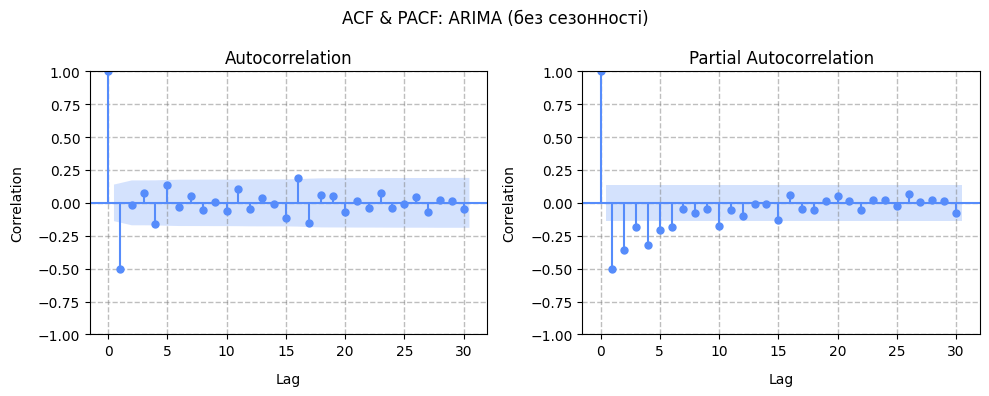

In [10]:
# Graphic results

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Input data
lags = 30
data_set = output_ar

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax = axes[0]
plot_acf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

ax = axes[1]
plot_pacf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

plt.suptitle(f"ACF & PACF: {ds_arima_name}")

plt.tight_layout()
plt.show()

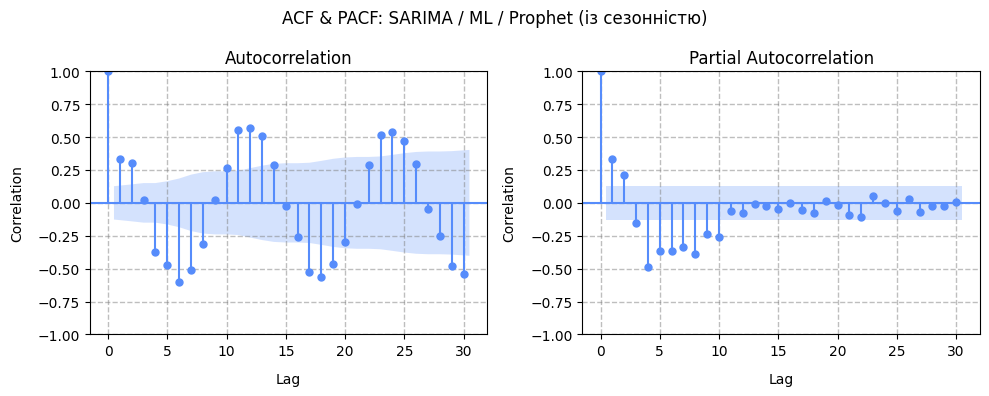

In [11]:
# Graphic results

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Input data
lags = 30
data_set = output_s

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax = axes[0]
plot_acf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

ax = axes[1]
plot_pacf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

plt.suptitle(f"ACF & PACF: {ds_seasonal_name}")

plt.tight_layout()
plt.show()

Висновок. За допомогою диференціювання було видалено тренди, але тест Дікі-Фуллера не виявляє сезонність і не забезпечує повної стаціонарності.

In [12]:
import apps.main as mn
import apps.reporter as rpt

# Input data
data_set = output_ar

# Solution

# знаходження q вручну
q_ar = mn.find_q_acf_manually(data_set)
p_ar = mn.find_p_pacf_manually(data_set)

rp = rpt.Reporter()
rp.add_item("Авторегресійний параметр, p", str(p_ar))
rp.add_item("Інтегрованості параметр, d", str(d_ar))
rp.add_item(f"Ковзного середнього параметр, q", str(q_ar))
rp.add_item("Структура ARIMA: (p, d, q)", f"({p_ar}, {d_ar}, {q_ar})")

# Print results
rp.print_pd_report(ds_arima_name)

Attribute,Result
"Авторегресійний параметр, p",6
"Інтегрованості параметр, d",1
"Ковзного середнього параметр, q",1
"Структура ARIMA: (p, d, q)","(6, 1, 1)"


Примітка. У цьому випадку параметр "p" був обраний автоматично й дуже суворо, а оскільки PACF показує плавне згасання, то це ознака ковзного середнього й у такому випадку обирається p = 0.

In [13]:
# Splitting data

import apps.main as mn
from IPython.display import display

# Input data
test_ratio = 0.2

# Solution
Y_train_ar, Y_test_ar = mn.train_test_split_by_order(df_arima, test_size=test_ratio)

# Print results
display(df_arima["y"].to_frame().describe().T.style.format("{:g}").set_caption("Статистика для всього часового ряду"))
display(Y_train_ar["y"].to_frame().describe().T.style.format("{:g}").set_caption("Статистика для тренувальної вибірки"))
display(Y_test_ar["y"].to_frame().describe().T.style.format("{:g}").set_caption("Статистика для тестової вибірки"))

,count,mean,std,min,25%,50%,75%,max
y,200,9.90923,5.92743,-0.61328,4.77539,9.74223,15.0867,20.6202


,count,mean,std,min,25%,50%,75%,max
y,160,7.8824,4.78374,-0.61328,3.95139,7.945,11.8846,17.4658


,count,mean,std,min,25%,50%,75%,max
y,40,18.0166,1.30813,15.0253,17.2144,18.0037,18.8552,20.6202


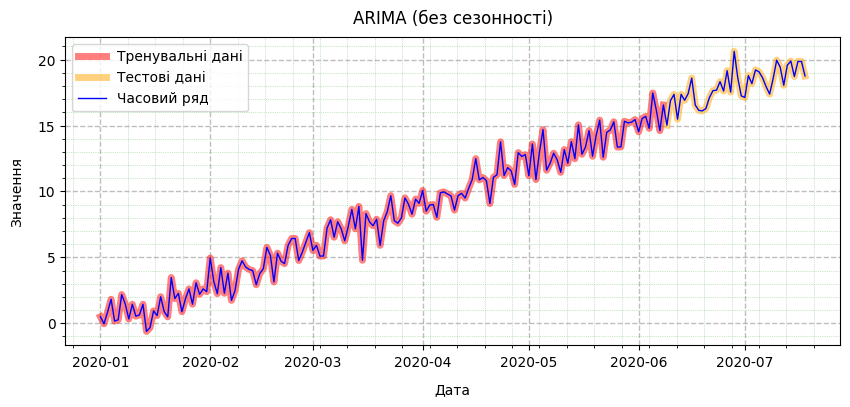

In [14]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(Y_train_ar["ds"], Y_train_ar["y"], linewidth=5.0, alpha=0.5, color="red", label="Тренувальні дані")
ax.plot(Y_test_ar["ds"], Y_test_ar["y"], linewidth=5.0, alpha=0.5, color="orange", label="Тестові дані")
ax.plot(df_arima["ds"], df_arima["y"], linewidth=1.0, color="blue", label="Часовий ряд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title(ds_arima_name, pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

In [15]:
# Training

import joblib
import apps.reporter as rpt
from pmdarima import auto_arima
from pathlib import Path

# Input data
load_model = True
model_file_name = "resources/auto_arima_search_parameters_ar.model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = auto_arima(
        Y_train_ar["y"],
        seasonal=False,  # без сезонності
        stepwise=True,  # алгоритм пошуку Бокса — Дженкінса, швидше ніж перебір (Grid Search)
        error_action="ignore",
        suppress_warnings=True,
        # n_jobs=-1, # використовувати коли  stepwise=False
    )
    # save model
    joblib.dump(model, model_file_name)

rp = rpt.Reporter()
rp.add_item("Авторегресійний параметр, p", str(model.order[0]))
rp.add_item("Інтегрованості параметр, d", str(model.order[1]))
rp.add_item(f"Ковзного середнього параметр, q", str(model.order[2]))
rp.add_item("Структура ARIMA: (p, d, q)", str(model.order))

# Print results
display(Markdown(f"### {ds_arima_name}"))
rp.print_pd_report("Автоматично підібрані параметри")
print(model.summary())

### ARIMA (без сезонності)

Attribute,Result
"Авторегресійний параметр, p",5
"Інтегрованості параметр, d",1
"Ковзного середнього параметр, q",0
"Структура ARIMA: (p, d, q)","(5, 1, 0)"


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  160
Model:               SARIMAX(5, 1, 0)   Log Likelihood                -224.489
Date:                Sat, 16 May 2026   AIC                            462.978
Time:                        17:54:28   BIC                            484.460
Sample:                             0   HQIC                           471.702
                                - 160                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3961      0.093      4.275      0.000       0.214       0.578
ar.L1         -0.9195      0.094     -9.794      0.000      -1.104      -0.736
ar.L2         -0.7850      0.124     -6.343      0.0

In [16]:
# Forecasting

import apps.main as mn
from statsmodels.tsa.arima.model import ARIMA

# Input data
n_periods_ar = len(Y_test_ar)

# Solution
Y_pred_ar = model.predict(n_periods=n_periods_ar)

model_check = ARIMA(Y_train_ar["y"], order=(p_ar, d_ar, q_ar), trend="t")
model_fit = model_check.fit(method_kwargs={"maxiter": 200})
Y_pred_ar_check = model_fit.forecast(steps=n_periods_ar)

# Print results
display(Markdown(f"**Оцінка за: auto_arima(...)**"))
_ = mn.calc_regres_metrics(Y_test_ar["y"], Y_pred_ar)
display(Markdown(f"**Оцінка за: manual ARIMA(...)**"))
_ = mn.calc_regres_metrics(Y_test_ar["y"], Y_pred_ar_check)

**Оцінка за: auto_arima(...)**

Attribute,Result
MAE,0.6920
MSE,0.7662
RMSE,0.8753
R² (коефіцієнт детермінації),0.5408
MAPE,0.0387


**Оцінка за: manual ARIMA(...)**

Attribute,Result
MAE,0.7003
MSE,0.7781
RMSE,0.8821
R² (коефіцієнт детермінації),0.5336
MAPE,0.0390


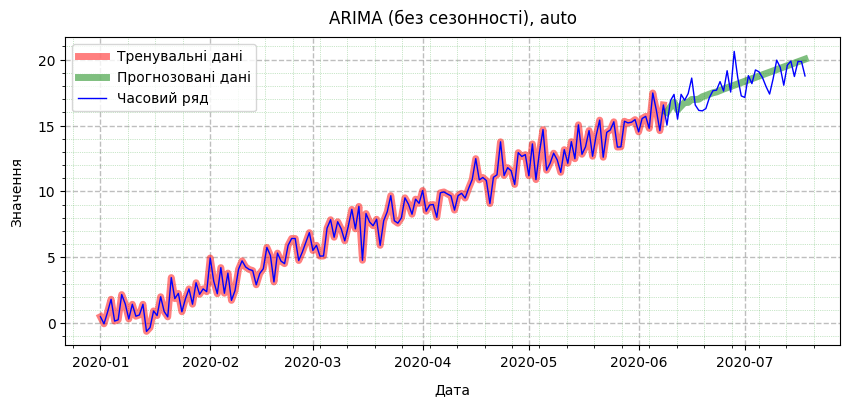

In [17]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(Y_train_ar["ds"], Y_train_ar["y"], linewidth=5.0, alpha=0.5, color="red", label="Тренувальні дані")
ax.plot(Y_test_ar["ds"], Y_pred_ar, linewidth=5.0, alpha=0.5, color="green", label="Прогнозовані дані")
ax.plot(df_arima["ds"], df_arima["y"], linewidth=1.0, color="blue", label="Часовий ряд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title(f"{ds_arima_name}, auto", pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

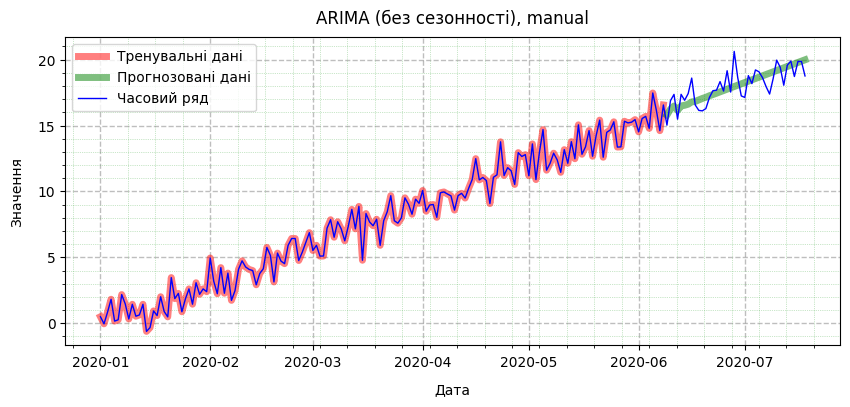

In [18]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(Y_train_ar["ds"], Y_train_ar["y"], linewidth=5.0, alpha=0.5, color="red", label="Тренувальні дані")
ax.plot(Y_test_ar["ds"], Y_pred_ar_check, linewidth=5.0, alpha=0.5, color="green", label="Прогнозовані дані")
ax.plot(df_arima["ds"], df_arima["y"], linewidth=1.0, color="blue", label="Часовий ряд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title(f"{ds_arima_name}, manual", pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

Примітка. Порівнюючи на даному кроці вручну визначенні параметри й параметри, які були отримані автоматично через модель ARIMA, виявляється, що результати доволі близькі, за винятком пропозиції застосувати p = 0 для ознаки ковзного середнього.

Висновок. Прогноз даної моделі більше схожий на прогноз тренду, ніж на повноцінний прогноз.

## ✅ Рішення 2.2

1. Визначити сезонність (період m)
2. Використати auto_arima (з seasonal=True)
3. Натренувати модель
4. Побудувати прогноз

**Відфільтрований спектр оригінального сигналу: SARIMA / ML / Prophet (із сезонністю)**

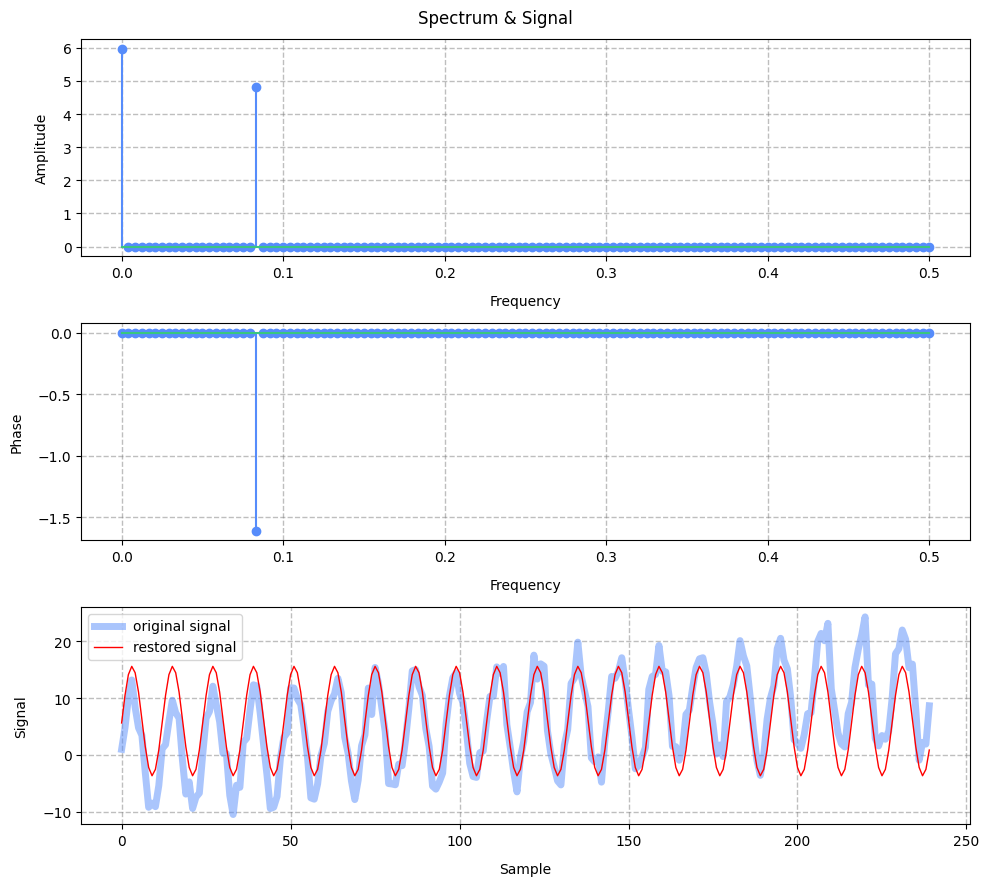

Attribute,Result
Індекс піка фазового спектра,20
"Частота спектра сезонності, [1/lag]",0.0833
"Період сезонності, [lag]",12


**Спектр оригінального сигналу: SARIMA / ML / Prophet (із сезонністю)**

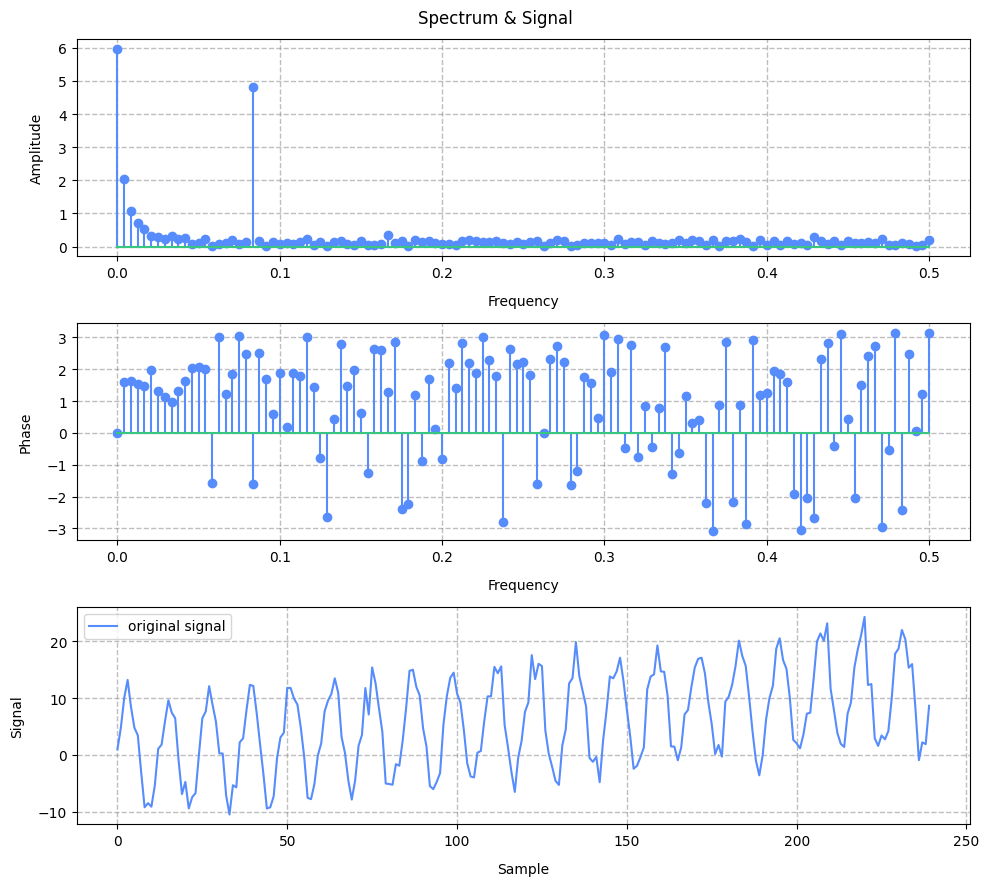

In [19]:
# Аналіз наявності сезонності

import numpy as np
import apps.fourier as fr
import apps.reporter as rpt

# Input data
amplitude_cut_level = 0.5
temp_df = df_seasonal.copy()
original_data = temp_df["y"].to_numpy()

# Solution
display(Markdown(f"**Відфільтрований спектр оригінального сигналу: {ds_seasonal_name}**"))
_, _, phases, frequencies, _ = fr.modify_signal_spectrum(original_data, vr_upper_lim=amplitude_cut_level,
                                                         figsize=(10, 9))

index_phase = np.argmax(np.abs(phases))
frequency = frequencies[index_phase]
seasonal_period_s = int(1 / frequency)

rp = rpt.Reporter()
rp.tolerance = 4
rp.add_item("Індекс піка фазового спектра", str(index_phase))
rp.add_item("Частота спектра сезонності, [1/lag]", rp.format_value(frequency))
rp.add_item("Період сезонності, [lag]", str(seasonal_period_s))

# Print/show results
rp.print_pd_report("Розраховані параметри сезонності")
display(Markdown(f"**Спектр оригінального сигналу: {ds_seasonal_name}**"))
fr.plot_signal_spectrum(original_data, figsize=(10, 9))

Примітка. Аналізуючи спектр оригінального сигналу, на амплітудно-частотному графіку помітні 2 великі піки по амплітуді, які вносять найбільший вплив. Після фільтрації та аналізу відновленого сигналу, де залишилися тільки необхідні компоненти, можемо побачити, що графік відновленого сигналу показує чітку сезонність. Найпростіше визначити, якій частоті відповідає сезонність, це проаналізувати фазо-частотний графік. Отримана частота вказує кількість циклів коливання на один лаг, отже, щоб знайти період коливання, необхідно отримати обернене значення до отриманої частоти. Отриманий період становить 12 лагів на 1 цикл коливання, що і є нашою сезонністю, а знаючи відношення лага до часу, можна визначити часовий період.

In [20]:
# Splitting data

import apps.main as mn
from IPython.display import display

# Input data
test_ratio = 0.2

# Solution
Y_train_s, Y_test_s = mn.train_test_split_by_order(df_seasonal, test_size=test_ratio)

# Print results
display(
    df_seasonal["y"].to_frame().describe().T.style.format("{:g}").set_caption("Статистика для всього часового ряду"))
display(Y_train_s["y"].to_frame().describe().T.style.format("{:g}").set_caption("Статистика для тренувальної вибірки"))
display(Y_test_s["y"].to_frame().describe().T.style.format("{:g}").set_caption("Статистика для тестової вибірки"))

,count,mean,std,min,25%,50%,75%,max
y,240,5.9702,7.96894,-10.4654,0.152121,5.91276,12.1978,24.2896


,count,mean,std,min,25%,50%,75%,max
y,192,4.71389,7.62193,-10.4654,-0.918146,4.58477,11.0233,20.1149


,count,mean,std,min,25%,50%,75%,max
y,48,10.9954,7.38947,-0.910539,3.56136,10.0223,18.0043,24.2896


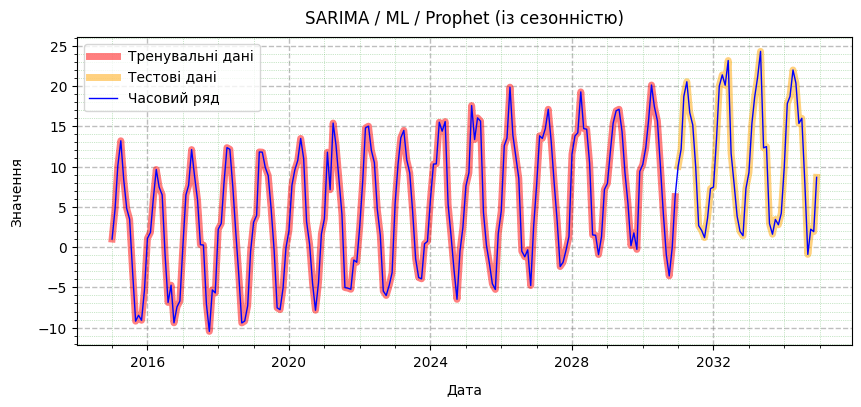

In [21]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(Y_train_s["ds"], Y_train_s["y"], linewidth=5.0, alpha=0.5, color="red", label="Тренувальні дані")
ax.plot(Y_test_s["ds"], Y_test_s["y"], linewidth=5.0, alpha=0.5, color="orange", label="Тестові дані")
ax.plot(df_seasonal["ds"], df_seasonal["y"], linewidth=1.0, color="blue", label="Часовий ряд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title(ds_seasonal_name, pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

In [22]:
# Training

import joblib
import apps.reporter as rpt
from pmdarima import auto_arima
from pathlib import Path

# Input data
load_model = True
model_file_name = "resources/auto_arima_search_parameters_s.model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = auto_arima(
        Y_train_s["y"],
        m=seasonal_period_s,  # період сезонності
        seasonal=True,  # із сезонністю
        stepwise=True,  # алгоритм пошуку Бокса — Дженкінса, швидше ніж перебір (Grid Search)
        error_action="ignore",
        suppress_warnings=True,
        # n_jobs=-1, # використовувати коли  stepwise=False
    )
    # save model
    joblib.dump(model, model_file_name)

rp = rpt.Reporter()
rp.add_item("Авторегресійний параметр, p", str(model.order[0]))
rp.add_item("Інтегрованості параметр, d", str(model.order[1]))
rp.add_item(f"Ковзного середнього параметр, q", str(model.order[2]))
rp.add_item("Авторегресійний сезонний параметр, P", str(model.seasonal_order[0]))
rp.add_item("Інтегрованості сезонний параметр, D", str(model.seasonal_order[1]))
rp.add_item(f"Ковзного середнього сезонний параметр, Q", str(model.seasonal_order[2]))
rp.add_item(f"Cезонності параметр, s", str(model.seasonal_order[-1]))
rp.add_item("Структура ARIMA: (p, d, q)x(P, D, Q)s",
            f"{model.order}X{model.seasonal_order[:-1]}[{model.seasonal_order[-1]}]")

# Print results
display(Markdown(f"### SARIMA (із сезонністю)"))
rp.print_pd_report("Автоматично підібрані параметри")
print(model.summary())

### SARIMA (із сезонністю)

Attribute,Result
"Авторегресійний параметр, p",2
"Інтегрованості параметр, d",1
"Ковзного середнього параметр, q",1
"Авторегресійний сезонний параметр, P",1
"Інтегрованості сезонний параметр, D",0
"Ковзного середнього сезонний параметр, Q",2
"Cезонності параметр, s",12
"Структура ARIMA: (p, d, q)x(P, D, Q)s","(2, 1, 1)X(1, 0, 2)[12]"


                                        SARIMAX Results                                        
Dep. Variable:                                       y   No. Observations:                  192
Model:             SARIMAX(2, 1, 1)x(1, 0, [1, 2], 12)   Log Likelihood                -422.757
Date:                                 Sat, 16 May 2026   AIC                            859.514
Time:                                         17:54:29   BIC                            882.280
Sample:                                              0   HQIC                           868.735
                                                 - 192                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0196      0.037     -0.523      0.601      -0.093       0

In [23]:
# Forecasting

import apps.main as mn

# Input data
n_periods_s = len(Y_test_s)

# Solution
Y_pred_s = model.predict(n_periods=n_periods_s)

# Print results
display(Markdown(f"**Оцінка за: auto_arima(...)**"))
_ = mn.calc_regres_metrics(Y_test_s["y"], Y_pred_s)

**Оцінка за: auto_arima(...)**

Attribute,Result
MAE,1.6357
MSE,4.7592
RMSE,2.1816
R² (коефіцієнт детермінації),0.9110
MAPE,0.3448


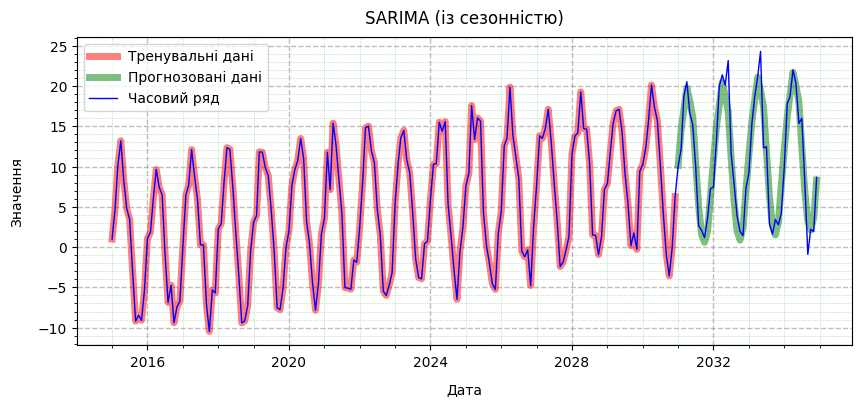

In [24]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(Y_train_s["ds"], Y_train_s["y"], linewidth=5.0, alpha=0.5, color="red", label="Тренувальні дані")
ax.plot(Y_test_s["ds"], Y_pred_s, linewidth=5.0, alpha=0.5, color="green", label="Прогнозовані дані")
ax.plot(df_seasonal["ds"], df_seasonal["y"], linewidth=1.0, color="blue", label="Часовий ряд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("SARIMA (із сезонністю)", pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

Висновок. Прогноз даної моделі більше схожий на прогноз сезонного тренду (гармонічна функція), ніж на повноцінний прогноз.

## ✅ Рішення 2.3

1. Натренувати модель:

```python
from prophet import Prophet

model = Prophet()
model.fit(df_seasonal)
```

2. Створити майбутні дати:

```python
future = model.make_future_dataframe(periods=24, freq='M')
```

3. Побудувати прогноз:

```python
forecast = model.predict(future)
```

4. Побудувати графіки:

* прогнозу
* компонентів (trend, seasonality)

In [25]:
# Training

import joblib
from prophet import Prophet
from pathlib import Path

# Input data
load_model = True
model_file_name = "resources/auto_arima_search_parameters_p.model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = Prophet()
    model.fit(Y_train_s)
    # save model
    joblib.dump(model, model_file_name)

# Print results
display(Markdown(f"### Prophet (із сезонністю)"))


### Prophet (із сезонністю)

In [26]:
# Forecasting

import apps.main as mn

# Input data
n_periods_s = len(Y_test_s)

# Solution
future = model.make_future_dataframe(periods=n_periods_s, freq='MS')
forecast = model.predict(future)
Y_pred_s = forecast[["ds", "yhat"]].rename(columns={"yhat": "y"}).iloc[-n_periods_s:]

# # Print results
display(Markdown(f"**Оцінка за: auto_arima(...)**"))
_ = mn.calc_regres_metrics(Y_test_s["y"], Y_pred_s["y"])

**Оцінка за: auto_arima(...)**

Attribute,Result
MAE,1.6727
MSE,4.6878
RMSE,2.1651
R² (коефіцієнт детермінації),0.9123
MAPE,0.3722


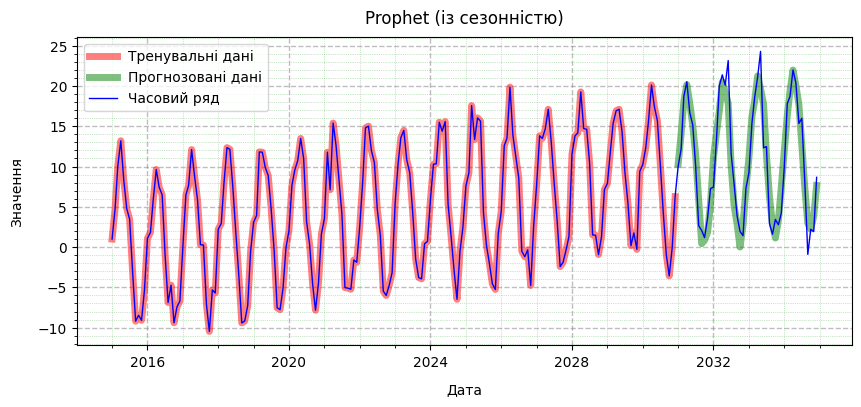

In [27]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(Y_train_s["ds"], Y_train_s["y"], linewidth=5.0, alpha=0.5, color="red", label="Тренувальні дані")
ax.plot(Y_pred_s["ds"], Y_pred_s["y"], linewidth=5.0, alpha=0.5, color="green", label="Прогнозовані дані")
ax.plot(df_seasonal["ds"], df_seasonal["y"], linewidth=1.0, color="blue", label="Часовий ряд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Prophet (із сезонністю)", pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

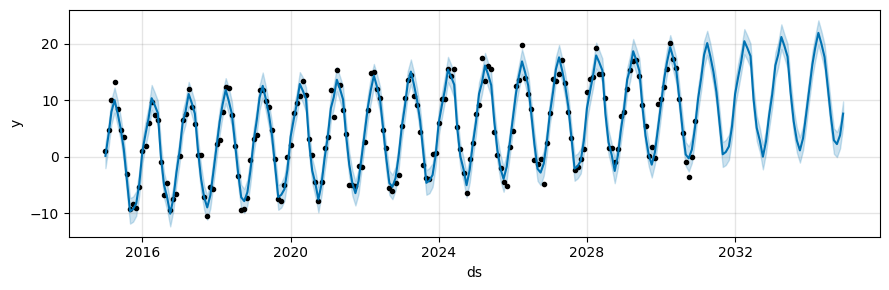

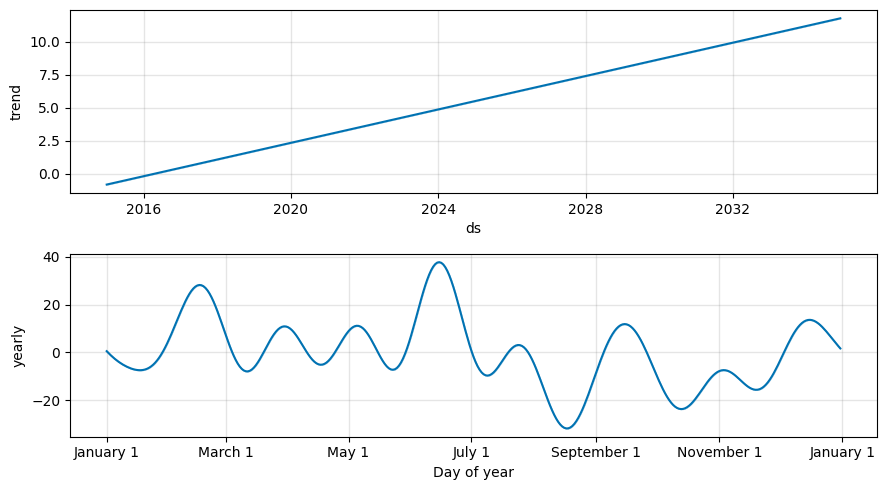

In [28]:
# Graphic results

model.plot(forecast, figsize=(9, 3))
_ = model.plot_components(forecast, figsize=(9, 5))

## ✅ Рішення 2.4

Обрати одну модель:

* XGBoost / RandomForest / CatBoost

1. Створити фічі:

   * lag_1, lag_2, lag_12
   * rolling статистики
   * календарні фічі (місяць, рік)

2. Розбити дані на train/test

3. Натренувати модель

4. Побудувати прогноз

In [29]:
# Data preparation

# Input data
df_sarima = df_seasonal.copy()
lags_sizes = [1, 2, 12]
rollings_sizes = [3, 12]
month_col_name = "month"
year_col_name = "year"

# Solution
df_sarima[month_col_name] = df_sarima["ds"].dt.month
df_sarima[year_col_name] = df_sarima["ds"].dt.year

for size in lags_sizes:
    col_name = f"lag_{size}"
    df_sarima[col_name] = df_sarima["y"].shift(size)

for size in rollings_sizes:
    col_name = f"rolling_mean_{size}"
    df_sarima[col_name] = df_sarima["y"].rolling(window=size).mean()

df_sarima = df_sarima.dropna()
S_data = df_sarima["ds"]
df_sarima = df_sarima.drop(columns="ds")

# Print results
display(df_sarima)

,y,month,year,lag_1,lag_2,lag_12,rolling_mean_3,rolling_mean_12
12,1.08392,1,2016,-5.38146,-9.08709,0.993428,-4.46154,0.874452
13,1.82344,2,2016,1.08392,-5.38146,4.77347,-0.824698,0.628616
14,5.91042,3,2016,1.82344,1.08392,10.0556,2.93926,0.283182
15,9.62542,4,2016,5.91042,1.82344,13.1961,5.78643,-0.0143713
16,7.43459,5,2016,9.62542,5.91042,8.39195,7.65681,-0.0941509
...,...,...,...,...,...,...,...,...
235,8.01784,8,2034,15.9879,15.3468,2.92457,13.1175,11.6793
236,-0.910539,9,2034,8.01784,15.9879,1.59588,7.6984,11.4704
237,2.22291,10,2034,-0.910539,8.01784,3.4279,3.11007,11.37
238,1.91617,11,2034,2.22291,-0.910539,2.76831,1.07618,11.299


In [30]:
# Splitting data

import apps.main as mn
from IPython.display import display

# Input data
test_ratio = 0.2
target_value = "y"

# Solution
X_data = df_sarima.drop(columns=[target_value])
Y_data = df_sarima[target_value]

S_train, S_test = mn.train_test_split_by_order(S_data, test_size=test_ratio)
X_train, X_test = mn.train_test_split_by_order(X_data, test_size=test_ratio)
Y_train, Y_test = mn.train_test_split_by_order(Y_data, test_size=test_ratio)

# Print results
display(df_sarima.describe().T.style.format("{:g}").set_caption("Статистика для всього часового ряду"))
display(X_train.describe().T.style.format("{:g}").set_caption("Статистика для тренувальної вибірки"))
display(Y_train.to_frame().describe().T.style.format("{:g}").set_caption("Статистика для тренувальної вибірки"))
display(X_test.describe().T.style.format("{:g}").set_caption("Статистика для тестової вибірки"))
display(Y_test.to_frame().describe().T.style.format("{:g}").set_caption("Статистика для тестової вибірки"))

,count,mean,std,min,25%,50%,75%,max
y,228,6.23879,7.90241,-10.4654,0.245268,6.47517,12.3377,24.2896
month,228,6.5,3.45965,1,3.75,6.5,9.25,12
year,228,2025,5.48928,2016,2020,2025,2030,2034
lag_1,228,6.17723,7.9381,-10.4654,0.204491,6.36732,12.3377,24.2896
lag_2,228,6.12897,7.99735,-10.4654,0.152121,6.36732,12.3377,24.2896
lag_12,228,5.67017,7.88073,-10.4654,-0.0646904,5.3983,12.0259,24.2896
rolling_mean_3,228,6.18166,7.23099,-8.62951,0.239018,6.03993,11.7476,21.5411
rolling_mean_12,228,5.96928,3.5801,-0.630583,3.34791,6.1292,9.0867,12.1433


,count,mean,std,min,25%,50%,75%,max
month,183,6.42623,3.4821,1,3,6,9,12
year,183,2023.13,4.41579,2016,2019,2023,2027,2031
lag_1,183,4.98071,7.56587,-10.4654,-0.523742,4.762,11.6554,20.1149
lag_2,183,4.86461,7.61794,-10.4654,-0.725902,4.69416,11.3687,20.1149
lag_12,183,4.56686,7.56524,-10.4654,-0.920243,4.47539,10.896,19.8499
rolling_mean_3,183,4.98589,6.85752,-8.62951,-0.754479,5.00739,10.9799,17.7354
rolling_mean_12,183,4.78612,2.94203,-0.630583,2.61807,4.5692,7.01178,9.84052


,count,mean,std,min,25%,50%,75%,max
y,183,5.11234,7.59408,-10.4654,-0.493169,5.31528,11.7796,20.1149


,count,mean,std,min,25%,50%,75%,max
month,45,6.8,3.38848,1,4,7,10,12
year,45,2032.6,1.09545,2031,2032,2033,2034,2034
lag_1,45,11.0431,7.62551,-0.910539,3.4279,10.0164,18.5895,24.2896
lag_2,45,11.2707,7.4987,-0.910539,3.60585,11.6418,18.5895,24.2896
lag_12,45,10.157,7.61723,-3.57969,3.4279,10.0164,16.6925,24.2896
rolling_mean_3,45,11.0445,6.71629,1.07618,4.54055,10.6329,17.4569,21.5411
rolling_mean_12,45,10.7808,0.907495,8.96837,10.0029,10.9619,11.5822,12.1433


,count,mean,std,min,25%,50%,75%,max
y,45,10.8197,7.54269,-0.910539,3.4279,9.96939,17.8092,24.2896


In [31]:
# Training

import joblib
from pathlib import Path
from xgboost import XGBRegressor

# Input data
load_model = True
model_file_name = "resources/auto_arima_search_parameters_ml.model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.05,
        eval_metric='logloss',
        n_jobs=-1
    )
    model.fit(X_train, Y_train, verbose=0)
    # save model
    joblib.dump(model, model_file_name)

Y_pred_xgboost = model.predict(X_test)

# Print results
display(Markdown(f"### ML - XGBoost (із сезонністю)"))
_ = mn.calc_regres_metrics(Y_test, Y_pred_xgboost)


### ML - XGBoost (із сезонністю)

Attribute,Result
MAE,2.8850
MSE,12.5279
RMSE,3.5395
R² (коефіцієнт детермінації),0.7748
MAPE,0.5388


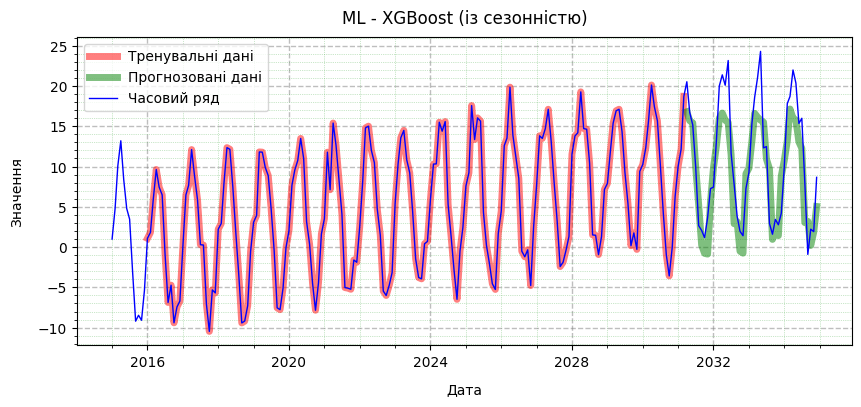

In [32]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(S_train, Y_train, linewidth=5.0, alpha=0.5, color="red", label="Тренувальні дані")
ax.plot(S_test, Y_pred_xgboost, linewidth=5.0, alpha=0.5, color="green", label="Прогнозовані дані")
ax.plot(df_seasonal["ds"], df_seasonal["y"], linewidth=1.0, color="blue", label="Часовий ряд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("ML - XGBoost (із сезонністю)", pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

## ✅ Рішення 3

Для кожної моделі оцінити:
* чи модель ловить тренд
* чи модель ловить сезонність
* чи є систематичні помилки


Систематичні помилки:
- **ЗЗ**: заниження або завищення — лінія іде паралельно даним, тобто нижче або вище за них для усього тестового періоду
- **ЗР**: згасання або розходження — лінія стрімко росте вгору або ж навпаки, прогноз відстає від реальних даних
- **ФА**: фази або амплітуди — лінія зсунута по фазі або ж масштаб менший або більший від тестового періоду

In [33]:
import apps.reporter as rpt

# Input data

# Solution
display(Markdown(f"### Графічна оцінка моделей:"))

rp = rpt.Reporter()
rp.add_item("Ловить тренд", "так")
rp.add_item("Ловить сезонність", "сезонність відсутня")
rp.add_item("Чи є систематичні помилки", f"ні")
rp.print_pd_report("ARIMA")

rp = rpt.Reporter()
rp.add_item("Ловить тренд", "так")
rp.add_item("Ловить сезонність", "так")
rp.add_item("Чи є систематичні помилки", f"ні")
rp.print_pd_report("SARIMA")

rp = rpt.Reporter()
rp.add_item("Ловить тренд", "так")
rp.add_item("Ловить сезонність", "так")
rp.add_item("Чи є систематичні помилки", f"ні")
rp.print_pd_report("Prophet")

rp = rpt.Reporter()
rp.add_item("Ловить тренд", "ні")
rp.add_item("Ловить сезонність", "так")
rp.add_item("Чи є систематичні помилки", f"так, це ЗР і ФА")
rp.print_pd_report("ML - XGBoost")


### Графічна оцінка моделей:

Attribute,Result
Ловить тренд,так
Ловить сезонність,сезонність відсутня
Чи є систематичні помилки,ні


Attribute,Result
Ловить тренд,так
Ловить сезонність,так
Чи є систематичні помилки,ні


Attribute,Result
Ловить тренд,так
Ловить сезонність,так
Чи є систематичні помилки,ні


Attribute,Result
Ловить тренд,ні
Ловить сезонність,так
Чи є систематичні помилки,"так, це ЗР і ФА"


## ✅ Рішення 4

Для кожної моделі обчислити:

* MAE
* RMSE
* MAPE

Порівняти:

* ARIMA (manual vs auto)
* SARIMA vs Prophet
* Prophet vs ML